In [7]:
import sys
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

#---wordnet---
import nltk
from nltk.corpus import wordnet as wn
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)
FILLERS = {"also", "being", "however", "thus", "therefore", "would", "could", "should",
           "may", "might", "must", "shall", "said", "say", "says", "get", "got", "make",
           "made", "go", "went", "one", "two", "like", "well", "even", "much", "many", "us"}
AUX_LEMMAS = {"be", "have", "do"}
stop_words = set(stopwords.words("english")) | FILLERS | AUX_LEMMAS

#----graph visualization-----
from networkx.drawing.nx_pydot import graphviz_layout
import networkx as nx
import matplotlib.pyplot as plt

print("Python path:", sys.executable)
print("Torch version:", torch.__version__)

print("GPU:", torch.cuda.get_device_name(0))
print("PyTorch:", torch.__version__)
print("CUDA:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("Capability:", torch.cuda.get_device_capability())

Python path: /usr/local/bin/python3.12
Torch version: 2.14.1+cu130
GPU: NVIDIA GeForce RTX 5060 Ti
PyTorch: 2.14.1+cu130
CUDA: 13.0
CUDA available: True
Capability: (12, 0)


download Qwen2.5-7B-Instuct weight once and save in local file named "hf_cache"

In [2]:
model_id = "Qwen/Qwen2.5-7B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    dtype=torch.bfloat16,
    device_map="cuda:0"
)

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

In [3]:
def distance_to_lca(synset1, synset2):
    lca = synset1.lowest_common_hypernyms(synset2)[0]
    return synset1.shortest_path_distance(lca)

dog = wn.synsets('dog')[0]
cat = wn.synsets('cat')[0]
chair = wn.synsets('chair')[0]
canine = wn.synset('canine.n.02') 

print(f"Distance between dog and canine: {distance_to_lca(dog, canine)}")
print(f"Distance between dog and cat: {distance_to_lca(dog, cat)}")
print(f"Distance between dog and chair: {distance_to_lca(dog, chair)}")

Distance between dog and canine: 1
Distance between dog and cat: 2
Distance between dog and chair: 5


In [4]:
G = nx.DiGraph()

def get_synset(term):
    """
        Handle WordNet synset IDs containing dots
        # - lemma: The base word (e.g., 'canine')
        # - part_of_speech: 'n' (noun), 'v' (verb), 'a' (adjective), 'r' (adverb)
        # - sense_index: The specific meaning ID (e.g., '02')
    """
    if '.' in term:
        return wn.synset(term)
    else:
        return wn.synsets(term)[0]

def distance_to_lca(synset1, synset2):
    """
        Calculates the semantic distance between two synsets via their Lowest Common Hypernym (LCA).
        Uses the longest path to the LCA to ensure all fine-grained hierarchical steps are counted. 
        Since WordNet allows multiple paths to the same hypernym, taking the longest path prevents 
        shortcuts and preserves the most accurate and specific semantic meaning.
    """
    lca = synset1.lowest_common_hypernyms(synset2)[0]
    return synset1.longest_path_distance(lca)

def add_path(synset, lca):
    paths = synset.hypernym_paths()
    for path in paths:
        if lca in path:
            lca_index = path.index(lca)
            segment = path[lca_index:]
            
            for i in range(len(segment) - 1):
                parent = segment[i].name()
                child = segment[i+1].name()
                G.add_edge(parent, child)
            break

def add_word_pair(word1, word2):
    w1 = get_synset(word1)
    w2 = get_synset(word2)

    lca = w1.lowest_common_hypernyms(w2)[0]
    
    add_path(w1, lca)
    add_path(w2, lca)
    
def draw_unified_tree(height_size=12, width_size=7):
    G.graph['rankdir'] = 'LR'
    pos = graphviz_layout(G, prog="dot")
    plt.figure(figsize=(height_size,width_size))

    nx.draw(
        G, 
        pos, 
        with_labels=True, 
        node_color="red", 
        node_size=500,
        font_weight="normal",
        font_size=10,
        arrows=True,
        arrowsize=10,
        edge_color="gray"
    )

    plt.margins(0.05)
    plt.title("test graph", fontsize=20)
    # plt.savefig("wordnet_tree_high_res.png", dpi=300, bbox_inches='tight') #save img as local file
    plt.show()

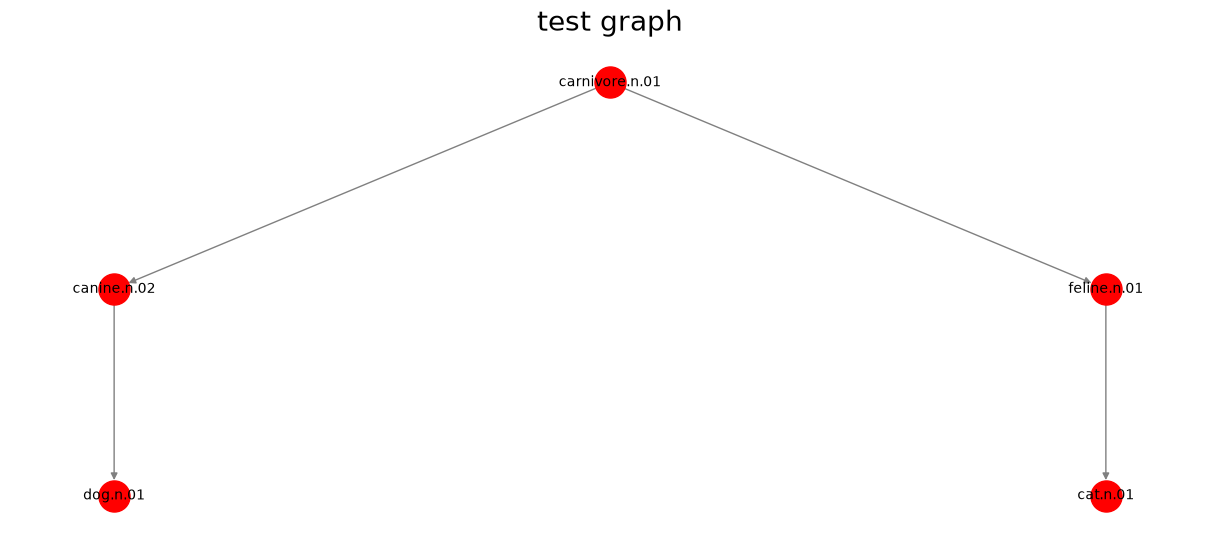

In [19]:
add_word_pair("dog", "cat")
draw_unified_tree(12,5)
G.clear()

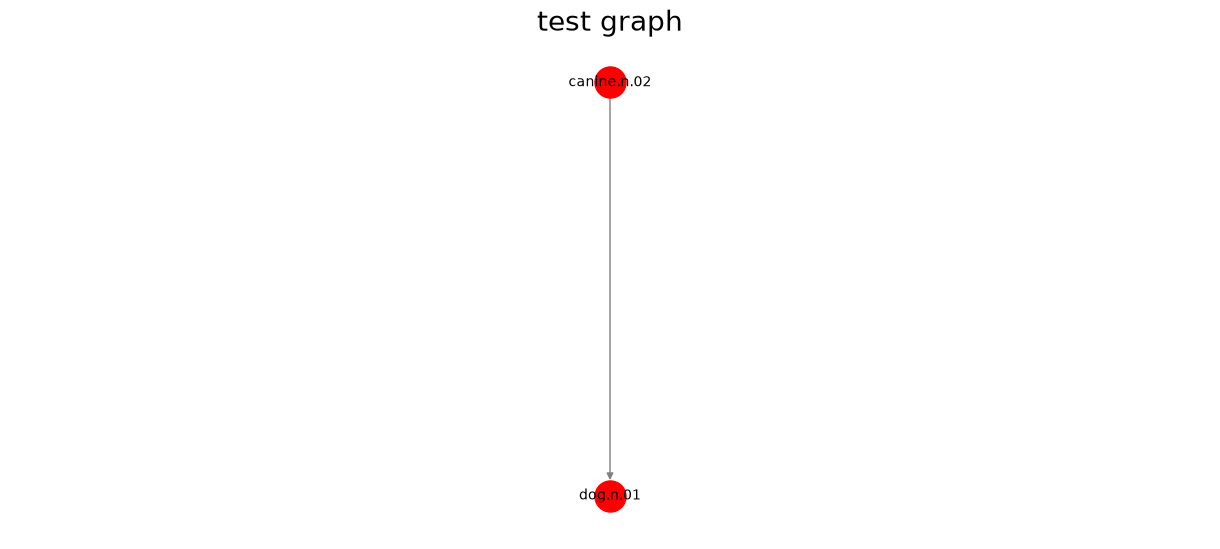

In [22]:
add_word_pair("dog", "canine.n.02")
draw_unified_tree(12,5)
G.clear()

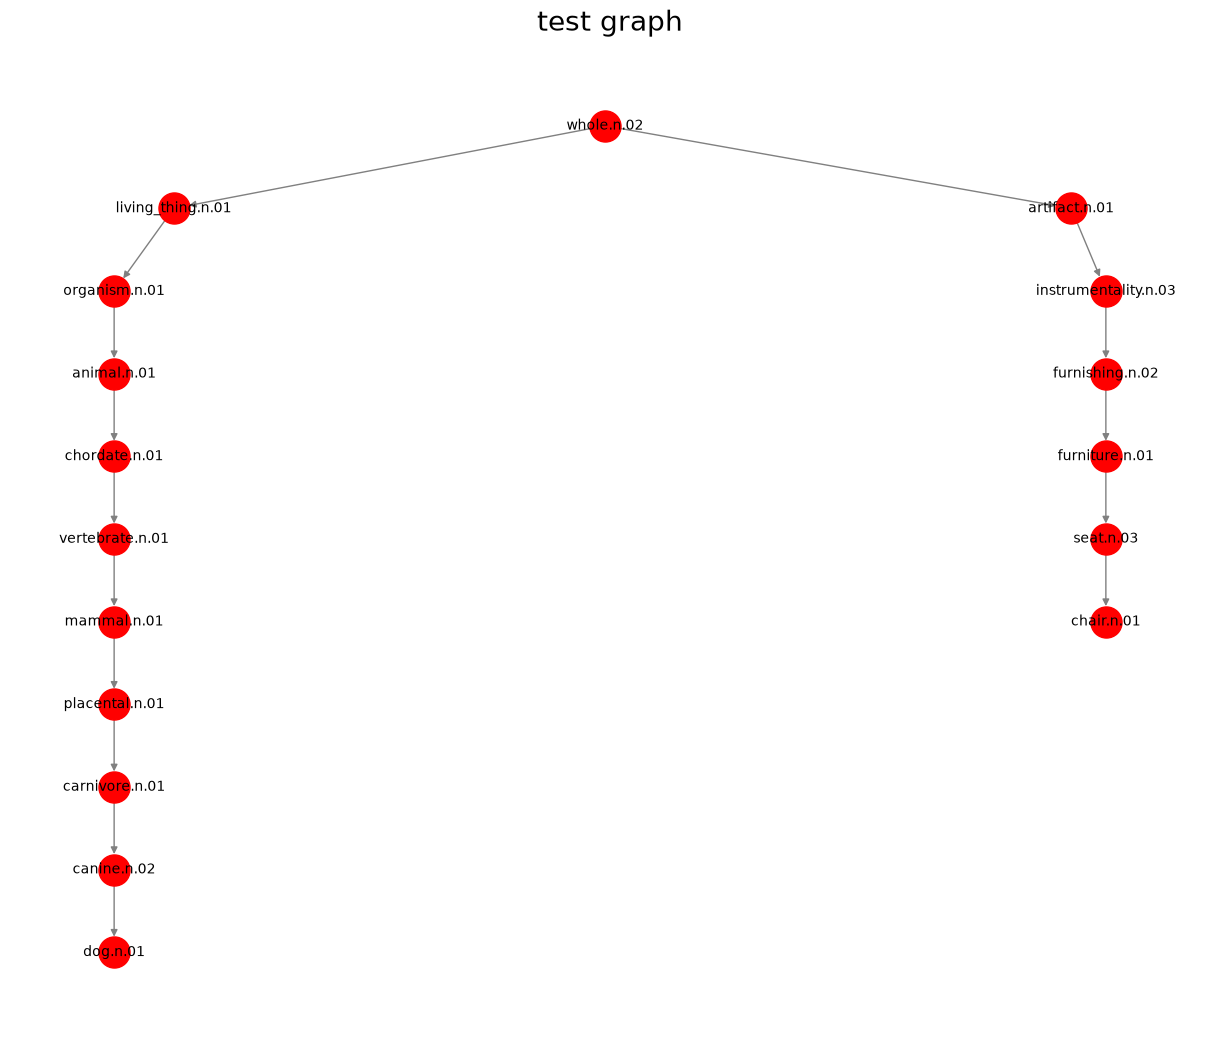

In [24]:
add_word_pair("dog", "chair")
draw_unified_tree(12,10)
G.clear()

In [8]:
import torch.nn.functional as F

def analyze_semantic_divergence(text):
    text_words = text.split()
    depths = []
    words_on_x = []

    for i in range(1, len(text_words)):
        context = " ".join(text_words[:i])
        actual_next_word = text_words[i]

        clean_target_word = "".join([c for c in actual_next_word if c.isalpha()]).lower()
        if not clean_target_word or clean_target_word in stop_words:
            continue

        # שליפת המילה האמיתית מ-WordNet
        target_synsets = wn.synsets(clean_target_word)
        if not target_synsets:
            continue
        target_synset = target_synsets[0]

        batch = tokenizer(context, return_tensors="pt").to(model.device)
        with torch.no_grad():
            outputs = model(**batch)
            
            # שליפת הלוגיטים
            next_token_logits = outputs.logits[0, -1, :]
            
            # חילוץ 3 התחזיות החזקות ביותר
            top_k = 3
            top_k_probs, top_k_indices = torch.topk(F.softmax(next_token_logits, dim=-1), top_k)
            
            word_depths = []
            for idx in top_k_indices:
                pred_word = tokenizer.decode(idx).strip()
                clean_pred = "".join([c for c in pred_word if c.isalpha()]).lower()
                
                if not clean_pred or clean_pred in stop_words:
                    continue
                
                pred_synsets = wn.synsets(clean_pred)
                if not pred_synsets:
                    continue
                    
                pred_synset = pred_synsets[0]
                
                # חישוב ה-LCA
                lcas = target_synset.lowest_common_hypernyms(pred_synset)
                if lcas:
                    lca = lcas[0]
                    depth = lca.max_depth() 
                    word_depths.append(depth)
            
            # אם מצאנו עומקים, נמצע אותם ונשמור לגרף
            if word_depths:
                depths.append(sum(word_depths) / len(word_depths))
                words_on_x.append(clean_target_word)
                
    return depths, words_on_x


def draw_semantic_divergence(depths, words, title="Semantic Divergence", color='blue'):
    plt.figure(figsize=(15, 6))

    # חישוב דילוג אוטומטי אם הטקסט ארוך מדי כדי שהמילים לא יעלו אחת על השנייה
    step = max(1, len(words) // 20) 
    
    plt.plot(depths, color=color, marker='o', linewidth=2)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.ylabel("Average LCA Depth", fontsize=12)
    
    plt.xticks(range(0, len(words), step), words[::step], rotation=45, ha='right', fontsize=10)
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

Computer science is the study of computation, information, and automation.
Computer science spans theoretical disciplines (such as algorithms, theory of computation, and information theory) to applied disciplines (including the design and implementation of hardware and software).
Computer science is generally considered an area of academic research and distinct from computer programming.


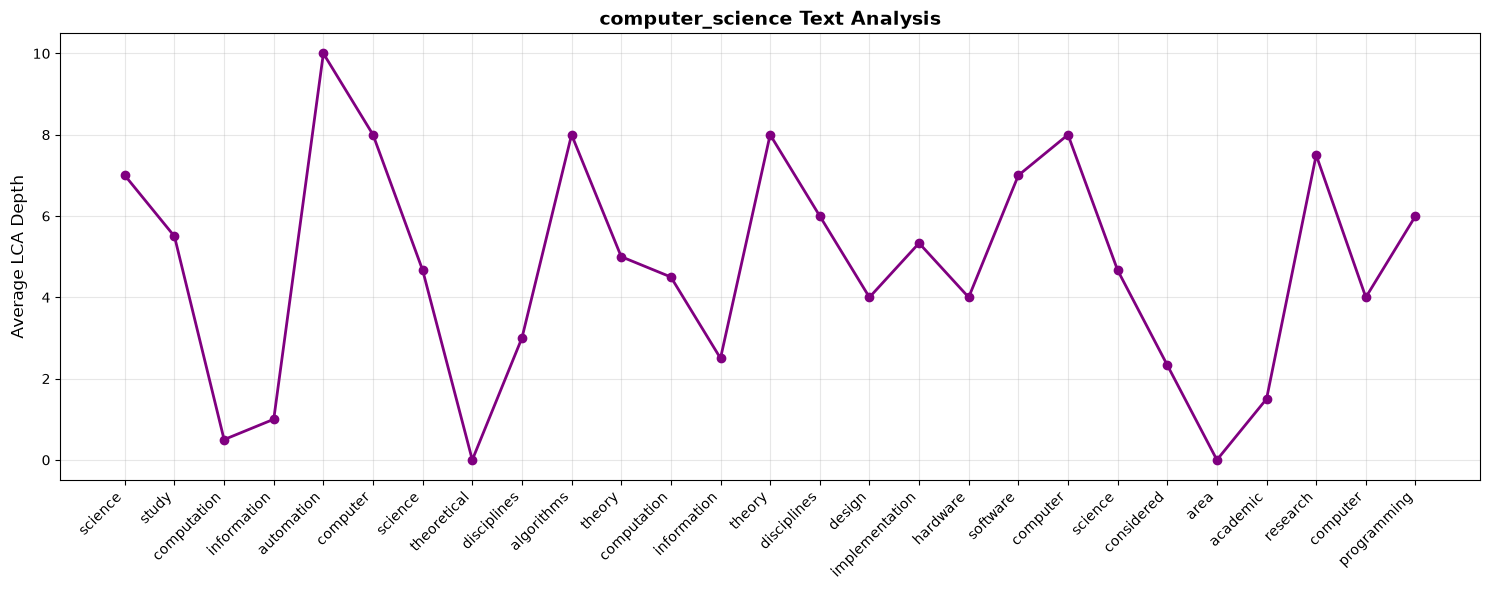

In [10]:
with open('./texts_data/factual_wiki_computer_science.txt', 'r') as file:
    content = file.read()
    print(content)
    
    depths, words = analyze_semantic_divergence(content)
    draw_semantic_divergence(depths, words, title="computer_science Text Analysis", color="purple")